<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 98 · Generalized Linear Models</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Generalized Linear Models</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Fit linear, logistic, and Poisson models from one glm() call, read rate ratios with an exposure offset, detect overdispersion, and repair it with the negative binomial, all library-first with statsmodels.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## Generalized linear models: one recipe, many outcomes
Library-first with `statsmodels`: the same `glm()` call fits linear, logistic, and Poisson models by swapping the family and link. We add an exposure offset, read rate ratios, detect overdispersion, and refit as negative binomial.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 1 &#183; ONE FRAMEWORK</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Three models, one glm() call</div>
<div style="color:#4a5578;margin-top:6px">Swap only the family and link to get linear, logistic, and Poisson regression from identical code.</div>
</div>

In [3]:
# A tiny illustration that the SAME function fits all three
families = {'Gaussian (linear)': sm.families.Gaussian(),
            'Binomial (logistic)': sm.families.Binomial(),
            'Poisson (count)': sm.families.Poisson()}
for name, fam in families.items():
    print(f'{name:22s} -> link = {fam.link.__class__.__name__}')

Gaussian (linear)      -> link = Identity
Binomial (logistic)    -> link = Logit
Poisson (count)        -> link = Log


<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 2 &#183; POISSON + OFFSET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit a count model and read rate ratios</div>
<div style="color:#4a5578;margin-top:6px">Model claims with a log(exposure) offset; coefficients exponentiate to rate ratios.</div>
</div>

In [4]:
try:
    claims = pd.read_excel('../../data/ch98_claims.xlsx', sheet_name='Policies')
except FileNotFoundError:
    claims = pd.read_excel(BASE + 'ch98_claims.xlsx', sheet_name='Policies')
print(claims.shape, ' mean claims = %.2f' % claims.claims.mean())
claims.head(3)

(500, 6)  mean claims = 2.81


,policy_id,driver_age,car_age,region,exposure_years,claims
0,C5000,37,6,urban,0.54,0
1,C5001,72,7,urban,0.76,3
2,C5002,60,9,suburban,0.34,4


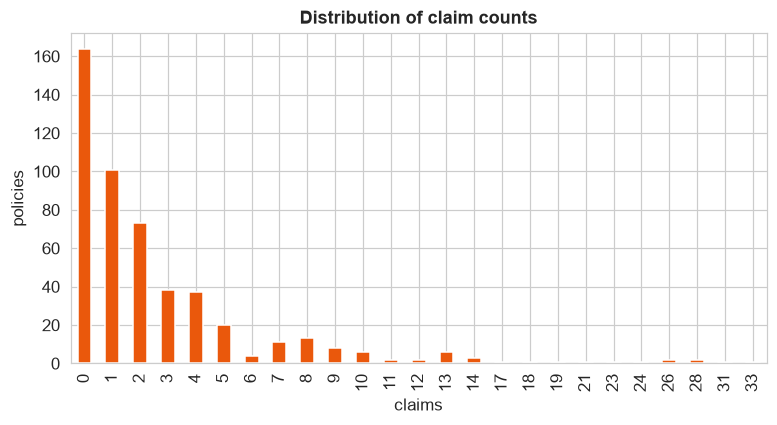

In [5]:
# EXPLORE FIRST: the count distribution is right-skewed with many zeros
fig, ax = plt.subplots(figsize=(7.2,4))
claims.claims.value_counts().sort_index().plot(kind='bar', color=ORG, ax=ax)
ax.set(title='Distribution of claim counts', xlabel='claims', ylabel='policies'); plt.tight_layout(); plt.show()

In [6]:
claims['off'] = np.log(claims['exposure_years'])
pois = smf.glm('claims ~ driver_age + car_age + C(region)', claims,
               family=sm.families.Poisson(), offset=claims['off']).fit()
rr = np.exp(pois.params); ci = np.exp(pois.conf_int())
print(pd.DataFrame({'rate_ratio': rr.round(3), 'CI_low': ci[0].round(3), 'CI_high': ci[1].round(3)}))
print(f"\nPer +10 years of driver age: rate ratio = {np.exp(pois.params['driver_age']*10):.2f}")
print(f"Urban vs rural: rate ratio = {np.exp(pois.params['C(region)[T.urban]']):.2f}")

                       rate_ratio  CI_low  CI_high
Intercept                   4.987   3.986    6.241
C(region)[T.suburban]       1.491   1.232    1.804
C(region)[T.urban]          2.366   1.987    2.817
driver_age                  0.976   0.973    0.979
car_age                     1.028   1.018    1.037

Per +10 years of driver age: rate ratio = 0.79
Urban vs rural: rate ratio = 2.37


**Reading rate ratios and the offset.** Poisson regression models the *log* of the expected count, so a raw coefficient is a change in log-rate. Exponentiate it (e^coef) and you get a **rate ratio**: the factor by which the expected number of claims multiplies per one-unit rise in the predictor. Below 1 lowers the rate (older drivers), above 1 raises it (urban). The **offset** log(exposure_years) is what turns a raw count into a rate: because it enters with a fixed coefficient of 1, the model compares claims *per year insured*, so a policy observed for half a year is not unfairly credited with fewer claims.

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; STEP 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Detect overdispersion</div>
<div style="color:#4a5578;margin-top:6px">Poisson assumes variance = mean. Bin the data and run the Pearson test; here the variance is far larger.</div>
</div>

mean = 2.81   variance = 20.56   ratio = 7.3x
Pearson chi2 / df = 4.83   (near 1 if Poisson holds)


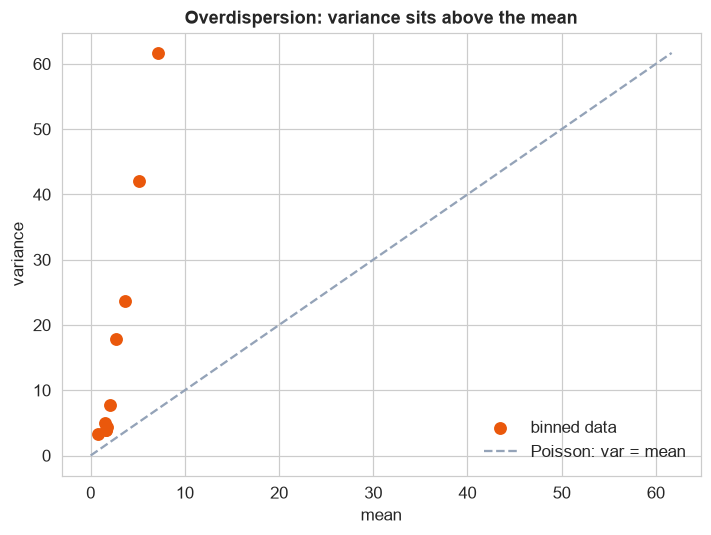

In [7]:
print(f'mean = {claims.claims.mean():.2f}   variance = {claims.claims.var():.2f}   ratio = {claims.claims.var()/claims.claims.mean():.1f}x')
print(f'Pearson chi2 / df = {pois.pearson_chi2/pois.df_resid:.2f}   (near 1 if Poisson holds)')
claims['mu'] = pois.mu
g = claims.assign(b=pd.qcut(claims.mu,10,duplicates='drop')).groupby('b', observed=True).claims.agg(['mean','var'])
fig, ax = plt.subplots(figsize=(6.6,5))
ax.scatter(g['mean'], g['var'], s=55, color=ORG, zorder=3, label='binned data')
hi = max(g['mean'].max(), g['var'].max())
ax.plot([0,hi],[0,hi], ls='--', color=GREY, label='Poisson: var = mean')
ax.set(title='Overdispersion: variance sits above the mean', xlabel='mean', ylabel='variance'); ax.legend()
plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 4 &#183; THE FIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Negative binomial: same rate ratios, honest errors</div>
<div style="color:#4a5578;margin-top:6px">Refit with a family that allows variance > mean. AIC drops sharply and the standard errors grow to their true size.</div>
</div>

In [8]:
nb = smf.glm('claims ~ driver_age + car_age + C(region)', claims,
             family=sm.families.NegativeBinomial(alpha=1.2), offset=claims['off']).fit()
cmp = pd.DataFrame({'RR_poisson': np.exp(pois.params).round(3),
                    'SE_poisson': pois.bse.round(3),
                    'RR_negbin': np.exp(nb.params).round(3),
                    'SE_negbin': nb.bse.round(3)})
print(cmp)
print(f'\nAIC   Poisson = {pois.aic:.0f}   Negative Binomial = {nb.aic:.0f}  (lower is better)')
print('Rate ratios barely move; the standard errors roughly double. Poisson was over-confident.')

                       RR_poisson  SE_poisson  RR_negbin  SE_negbin
Intercept                   4.987       0.114      4.625      0.227
C(region)[T.suburban]       1.491       0.097      1.558      0.176
C(region)[T.urban]          2.366       0.089      2.303      0.166
driver_age                  0.976       0.002      0.978      0.003
car_age                     1.028       0.005      1.028      0.010

AIC   Poisson = 2881   Negative Binomial = 2068  (lower is better)
Rate ratios barely move; the standard errors roughly double. Poisson was over-confident.


**Why the negative binomial matters.** Poisson and negative binomial give almost the *same* rate ratios, so the story about which factors matter is unchanged. What changes is certainty. Poisson assumes variance = mean; when the data are overdispersed, that makes the standard errors too small, so every p-value and confidence interval looks more significant than it should. The negative binomial adds a dispersion parameter that lets variance exceed the mean, which roughly doubles the standard errors here and slashes the AIC from 2881 to 2068. Same coefficients, honest error bars.

## Putting it all together: the count-model workflow

The GLM framework let us fit a count outcome with the same recipe as linear and logistic regression, just a different family and link.

**Step 1, explore.** The claim counts were small and right-skewed (mean about 2.8, variance about 20, a third of policies at zero). Variance far above the mean was an early warning that plain Poisson might not fit.

**Step 2, fit.** We chose the **Poisson family with a log link** for counts, and added a **log(exposure) offset** so the model predicts a rate per year insured rather than a raw count.

**Step 3, evaluate, and rate ratios.** Exponentiating the coefficients gave rate ratios: each +10 years of driver age multiplies the claim rate by 0.79, and urban policies file at about 2.4 times the rural rate.

**Step 4, check the conditions (overdispersion).** The count-model condition is variance = mean. We tested it with the **Pearson chi-square / df** (4.8, far above the ideal 1) and by binning the data (variance sat well above the mean). Both said the counts are overdispersed, so Poisson's standard errors cannot be trusted.

**The remedy.** We refit as a **negative binomial**, which adds a dispersion parameter so variance can exceed the mean. The rate ratios barely moved, but the standard errors roughly doubled (honest now) and the AIC fell from 2881 to 2068, a much better fit.

**Takeaway.** Every regression in this Part is one GLM with a different family and link: identity/Normal for numbers, logit/Binomial for yes-no, log/Poisson for counts. Overdispersion is to Poisson what heteroscedasticity is to linear regression, the diagnostic that keeps your p-values believable.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>